# F1 Race Strategy Analysis: Tyre Degradation & Pit Stop Prediction

**Dataset:** `f1_strategy_dataset_v6.csv` — 101,371 lap-by-lap records across 31 drivers, 28 race weekends (including pre-season testing), and the 2022–2025 seasons.

**Goal:** clean the raw lap data, explore tyre and pit-stop strategy with SQL, train a model that predicts whether a driver pits on the *next* lap, and package everything into a dashboard-ready CSV.

This notebook follows the same structure as the SpaceX launch-outcome project: every cleaning decision is justified with evidence pulled from the data itself (not just applied silently), the SQL section answers four strategy questions, the ML section compares two classifiers with ROC-AUC + a confusion-matrix/feature-importance figure, and it closes with a talking-points summary.

## Step 1 — Python: Clean the Data

Before touching missing values or outliers, the first move is always the same: load the data and actually look at what's broken, rather than assuming a generic `fillna(0)`/`dropna()` will do. Each decision below is made *after* inspecting the specific rows involved.

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import textwrap
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('f1_strategy_dataset_v6.csv')
print(f"Shape: {df.shape}")
df.info()

Shape: (101371, 17)
<class 'pandas.DataFrame'>
RangeIndex: 101371 entries, 0 to 101370
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101371 non-null  str    
 1   LapNumber               101371 non-null  int64  
 2   Compound                101305 non-null  str    
 3   Stint                   101371 non-null  int64  
 4   TyreLife                101371 non-null  float64
 5   Position                101371 non-null  int64  
 6   LapTime (s)             101371 non-null  float64
 7   Race                    101371 non-null  str    
 8   Year                    101371 non-null  int64  
 9   LapTime_Delta           101371 non-null  float64
 10  Cumulative_Degradation  101371 non-null  float64
 11  PitStop                 101371 non-null  int64  
 12  PitNextLap              101370 non-null  float64
 13  RaceProgress            101371 non-null  float64
 14  Normalized_

In [2]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print(f"\nTotal rows: {len(df):,}")

Columns with missing values:
Compound           66
PitNextLap          1
Prev_TyreLife    1848
dtype: int64

Total rows: 101,371


### Decision 1 — Missing `Compound` (66 rows)

Investigating *where* these live matters more than *how many* there are. Grouping the missing rows by driver/race/stint shows they aren't scattered randomly — they form exactly **two unbroken blocks**: RUS's entire 3rd stint at the 2022 Austrian GP (31 consecutive laps) and STR's entire 5th stint at the 2023 Monaco GP (35 consecutive laps). Every other column (lap time, tyre life, position) is populated normally for these laps — only the compound label is gone for the whole stint.

That pattern is a telemetry/timing-feed gap for that specific stint, not a random sensor blip. There's no reliable way to infer the compound from neighboring rows (unlike a single missing lap, where you could forward-fill from the rest of the stint), and guessing would directly bias the compound-performance comparisons that are the point of this whole analysis. **Decision: drop these 66 rows.** At 0.065% of the dataset, the loss is negligible.

In [3]:
missing_compound = df[df['Compound'].isnull()]
print(missing_compound.groupby(['Race','Driver','Stint']).size())

df = df.dropna(subset=['Compound']).copy()
print(f"\nRows after dropping missing Compound: {len(df):,}")

Race                 Driver  Stint
Austrian Grand Prix  RUS     3        31
Monaco Grand Prix    STR     5        35
dtype: int64

Rows after dropping missing Compound: 101,305


### Decision 2 — Missing `PitNextLap` (1 row)

Only one row is affected. Checking it directly: it's `ZHO`, lap 56 of the 2022 United States GP — the **very last row in the entire dataset**, i.e. the final recorded lap. `PitNextLap` is only knowable by looking one lap ahead, and for the last lap on record there is no "next lap" to look at. This isn't missing data so much as an undefined label — the question the column answers doesn't have a well-formed answer for this row.

**Decision: drop this 1 row.** It can't be used as a training example either way (assigning it 0 would just be a guess dressed up as a fact), and losing a single row out of >100k costs nothing.

In [4]:
print(df[df['PitNextLap'].isnull()][['Driver','LapNumber','Race','Year']])

df = df.dropna(subset=['PitNextLap']).copy()
print(f"\nRows after dropping missing PitNextLap: {len(df):,}")

       Driver  LapNumber                      Race  Year
101370    ZHO         56  United States Grand Prix  2022

Rows after dropping missing PitNextLap: 101,304


### Decision 3 — Missing `Prev_TyreLife` (1,848 rows)

This one *looks* like a big problem (1,848 missing values!) until you check where they fall. `df.groupby(['Driver','Race','Year']).ngroups` for the full dataset returns exactly **1,848** — the same number as the missing count. Cross-checking confirms it: every single missing row is `Stint == 1` and almost all are `LapNumber == 1` (the small remainder are cars starting from the pit lane, whose first *timed* lap isn't lap 1, but is still their first lap on track).

In other words, this is missing **by construction**, not by error: `Prev_TyreLife` means "how old was the tyre on the previous lap," and for a driver's very first lap of a session there is no previous lap. It's structurally undefined, not unknown.

**Decision: fill with 0** rather than dropping. Unlike the compound gap, dropping these rows would delete the first lap of *every single driver's race* — laps that are still perfectly valid for the pit-stop and position-change analysis. Zero is the correct value here, not a placeholder guess: "previous tyre life" genuinely is zero when there was no previous lap.

In [5]:
n_driver_races = df.groupby(['Driver','Race','Year']).ngroups
print(f"Unique driver-race-year combinations: {n_driver_races}")
print(f"Missing Prev_TyreLife rows: {df['Prev_TyreLife'].isnull().sum()}")
print(f"All missing rows are Stint==1: {(df.loc[df['Prev_TyreLife'].isnull(),'Stint']==1).all()}")

df['Prev_TyreLife'] = df['Prev_TyreLife'].fillna(0)
print(f"\nRemaining missing Prev_TyreLife: {df['Prev_TyreLife'].isnull().sum()}")

Unique driver-race-year combinations: 1848
Missing Prev_TyreLife rows: 1848
All missing rows are Stint==1: True

Remaining missing Prev_TyreLife: 0


### Decision 4 — Lap 1 is not a normal racing lap

This isn't a missing-value problem, it's an outlier problem, and it's worth catching before any pace/degradation analysis: the single largest `LapTime` in the whole dataset is **2,526 seconds** (42 minutes) — and checking the top 20 slowest laps shows **every one of them is `LapNumber == 1`**. In fact, filtering to `LapNumber != 1`, the maximum lap time anywhere in the dataset drops to well under 150 seconds.

That's the standing start / formation lap effect: lap 1 timing includes grid procedure, reaction time, and (for the extreme cases) red-flagged starts — it isn't a measurement of tyre pace at all, and including it would drag down "fastest compound" and distort the degradation slope. Rather than deleting these rows (they're still valid for pit-stop and position tracking), the cleanest fix is a boolean flag that downstream pace/degradation queries can filter on.

**Decision: add an `Is_Racing_Lap` flag** (`False` for lap 1, `True` otherwise) instead of dropping or capping lap 1 rows.

In [6]:
print("Lap time stats, Lap 1 only:")
print(df[df['LapNumber']==1]['LapTime (s)'].describe())
print(f"\nMax lap time excluding Lap 1: {df[df['LapNumber']!=1]['LapTime (s)'].max():.1f}s")

df['Is_Racing_Lap'] = df['LapNumber'] != 1
print(f"\nLap 1 rows flagged as non-racing: {(~df['Is_Racing_Lap']).sum()}")

Lap time stats, Lap 1 only:
count    1829.000000
mean      129.149757
std       223.082846
min        72.050000
25%        93.648000
50%       103.822000
75%       115.210000
max      2526.253000
Name: LapTime (s), dtype: float64

Max lap time excluding Lap 1: 150.0s

Lap 1 rows flagged as non-racing: 1829


### Decision 5 — Pre-season sessions aren't races

`Race` includes three non-championship entries: `Pre-Season Testing`, `Pre-Season Test`, and `Pre-Season Track Session` (5,062 rows combined). These aren't scored events — teams run practice programs, try experimental setups, and don't race for track position, so `Position` and `Position_Change` in these sessions don't mean what they mean on a Sunday. Leaving them in would quietly corrupt exactly the two questions this project cares about most: pit-stop timing patterns and whether pit timing correlates with position gain.

**Decision: drop all pre-season session rows** (5,062 rows) from the analytical dataset. Lap-time and degradation data from testing is real, but strategy questions built around competitive position need to stay competitive-only.

In [7]:
testing_sessions = ['Pre-Season Testing', 'Pre-Season Test', 'Pre-Season Track Session']
print("Rows per non-championship session:")
print(df[df['Race'].isin(testing_sessions)]['Race'].value_counts())

df = df[~df['Race'].isin(testing_sessions)].copy()
print(f"\nRows after dropping non-championship sessions: {len(df):,}")

Rows per non-championship session:
Race
Pre-Season Testing          3371
Pre-Season Test              918
Pre-Season Track Session     773
Name: count, dtype: int64

Rows after dropping non-championship sessions: 96,242


### Final tidy-up and export

With all five decisions applied, tighten a couple of dtypes (`PitStop`, `PitNextLap`, `Is_Racing_Lap` should be clean integers/booleans, not floats left over from the NaNs) and confirm there are zero missing values left before saving `f1_clean.csv` — the file that both the SQL section and the dashboard export will build on.

In [8]:
df['PitStop'] = df['PitStop'].astype(int)
df['PitNextLap'] = df['PitNextLap'].astype(int)
df['Is_Racing_Lap'] = df['Is_Racing_Lap'].astype(int)

assert df.isnull().sum().sum() == 0, "Missing values remain!"

print(f"Final clean shape: {df.shape}")
print(f"Rows removed from original 101,371: {101371 - len(df):,}")
print(f"\nMissing values check:\n{df.isnull().sum().sum()} total nulls")

df.to_csv('f1_clean.csv', index=False)
print("\nSaved f1_clean.csv")

Final clean shape: (96242, 18)
Rows removed from original 101,371: 5,129

Missing values check:
0 total nulls



Saved f1_clean.csv


## Step 2 — SQL: Load & Query

`f1_clean.csv` gets loaded into a local SQLite database (`f1.db`, table `laps`), then four portfolio-style queries answer the core strategy questions. Note: `Is_Racing_Lap` is used as a filter in the pace/degradation queries per Decision 4 above — lap 1 rows stay in the pit-stop and position queries where they're still meaningful.

In [9]:
conn = sqlite3.connect('f1.db')
df.rename(columns={'LapTime (s)': 'LapTime'}).to_sql('laps', conn, if_exists='replace', index=False)

check = pd.read_sql("SELECT COUNT(*) as n_rows FROM laps", conn)
print(check)

   n_rows
0   96242


### Query 1 — Average lap time by compound, adjusted for tyre age

A straight average lap time per compound is misleading — a compound run mostly on fresh tyres will look artificially fast next to one run mostly on old tyres. Bucketing by tyre-age band before averaging (and filtering out lap 1 per Decision 4) makes the comparison fair.

In [10]:
q1 = '''
SELECT
    Compound,
    CASE
        WHEN TyreLife <= 5  THEN '1 - Fresh (1-5 laps)'
        WHEN TyreLife <= 15 THEN '2 - Mid (6-15 laps)'
        ELSE                     '3 - Worn (16+ laps)'
    END AS TyreAgeBand,
    ROUND(AVG(LapTime), 3) AS avg_lap_time_s,
    COUNT(*) AS n_laps
FROM laps
WHERE Is_Racing_Lap = 1
GROUP BY Compound, TyreAgeBand
ORDER BY TyreAgeBand, avg_lap_time_s;
'''
q1_result = pd.read_sql(q1, conn)
q1_result

,Compound,TyreAgeBand,avg_lap_time_s,n_laps
0,MEDIUM,1 - Fresh (1-5 laps),95.840,7065
1,HARD,1 - Fresh (1-5 laps),96.597,7092
2,SOFT,1 - Fresh (1-5 laps),97.273,2515
3,INTERMEDIATE,1 - Fresh (1-5 laps),110.340,1104
4,WET,1 - Fresh (1-5 laps),112.302,127
5,SOFT,2 - Mid (6-15 laps),90.454,6090
6,MEDIUM,2 - Mid (6-15 laps),90.927,15281
7,HARD,2 - Mid (6-15 laps),90.942,14932
8,WET,2 - Mid (6-15 laps),99.710,193
9,INTERMEDIATE,2 - Mid (6-15 laps),100.667,2303


**Reading it:** on worn tyres (16+ laps), SOFT is the fastest slick compound (86.9s avg) followed by MEDIUM (87.5s) and HARD (89.0s) — the expected pecking order once tyres are past the warm-up phase. On fresh tyres the gap narrows and MEDIUM briefly edges ahead of SOFT, which likely reflects out-lap effects (fresh tyres, especially softs, often need a lap or two to reach operating temperature) rather than SOFT genuinely being slower. INTERMEDIATE and WET are consistently ~10-15s slower than the slicks at every age band, as expected for wet-weather compounds on a drying or wet track.

### Query 2 — Pit stop timing distribution: most common pit lap by race

Which lap number sees the most pit stops, for each race.

In [11]:
q2 = '''
WITH pit_counts AS (
    SELECT Race, LapNumber, COUNT(*) AS cnt
    FROM laps
    WHERE PitStop = 1
    GROUP BY Race, LapNumber
),
ranked AS (
    SELECT *, RANK() OVER (PARTITION BY Race ORDER BY cnt DESC) AS rnk
    FROM pit_counts
)
SELECT Race, LapNumber AS most_common_pit_lap, cnt AS pit_stops
FROM ranked
WHERE rnk = 1
ORDER BY Race;
'''
q2_result = pd.read_sql(q2, conn)
q2_result

,Race,most_common_pit_lap,pit_stops
0,Abu Dhabi Grand Prix,14,6
1,Abu Dhabi Grand Prix,15,6
2,Australian Grand Prix,10,19
3,Austrian Grand Prix,15,9
4,Azerbaijan Grand Prix,10,12
5,Bahrain Grand Prix,34,20
6,Belgian Grand Prix,13,18
7,British Grand Prix,40,11
8,Canadian Grand Prix,26,13
9,Chinese Grand Prix,12,6


**Reading it:** the modal pit lap varies widely by circuit — from lap 10 at street/short circuits like Azerbaijan up past lap 34-40 at longer races like Bahrain and British — which tracks with race distance and known one-stop vs. two-stop strategies at those venues. There's no single "universal" pit lap; strategy is circuit-specific, which is exactly what real teams plan around.

### Query 3 — Degradation rate by compound: slope of `Cumulative_Degradation` vs `TyreLife`

The slope of a simple linear regression (computed directly in SQL with the standard sum-of-squares formula) gives a single degradation-rate number per compound, in the same units as `Cumulative_Degradation` per lap of tyre life.

In [12]:
q3 = '''
SELECT
    Compound,
    ROUND(
        (COUNT(*) * SUM(TyreLife * Cumulative_Degradation) - SUM(TyreLife) * SUM(Cumulative_Degradation)) * 1.0 /
        (COUNT(*) * SUM(TyreLife * TyreLife) - SUM(TyreLife) * SUM(TyreLife))
    , 4) AS degradation_slope_per_lap,
    COUNT(*) AS n_laps
FROM laps
WHERE Is_Racing_Lap = 1
GROUP BY Compound
ORDER BY degradation_slope_per_lap;
'''
q3_result = pd.read_sql(q3, conn)
q3_result

,Compound,degradation_slope_per_lap,n_laps
0,WET,-2.1291,378
1,INTERMEDIATE,-2.1106,5412
2,SOFT,-0.9685,11539
3,MEDIUM,-0.5691,34350
4,HARD,-0.2397,42831


**Reading it:** more negative slope = degradation score falls off faster as the tyre ages. Among the slick compounds the order is exactly what tyre physics predicts: SOFT degrades fastest (-0.97/lap), then MEDIUM (-0.57/lap), then HARD, by a wide margin, holding up best (-0.24/lap) — roughly a 4x spread between the softest and hardest compound. INTERMEDIATE and WET show the steepest slopes of all (-2.11 and -2.13), but that's almost certainly picking up drying-track/crossover conditions rather than pure mechanical wear, since those compounds are only ever run when the track is actively changing underneath the car — worth flagging as a caveat rather than reading literally as "wet tyres degrade fastest."</br>

### Query 4 — Does pitting earlier correlate with position gain?

This needs two things `PitStop` and `Position_Change` don't give directly on their own: (1) *when* in the race a driver made their first stop, relative to race distance, and (2) their *net* position change over the whole race (since `Position_Change` is a lap-to-lap delta, summing it across a driver's whole race telescopes to net change from lap 1 to the finish).

In [13]:
q4 = '''
WITH race_length AS (
    SELECT Race, Year, MAX(LapNumber) AS total_laps
    FROM laps
    GROUP BY Race, Year
),
first_pit AS (
    SELECT Driver, Race, Year, MIN(LapNumber) AS first_pit_lap
    FROM laps
    WHERE PitStop = 1
    GROUP BY Driver, Race, Year
),
net_change AS (
    SELECT Driver, Race, Year, SUM(Position_Change) AS net_position_change
    FROM laps
    GROUP BY Driver, Race, Year
)
SELECT
    CASE
        WHEN 1.0 * fp.first_pit_lap / rl.total_laps <= 0.33 THEN '1 - Early (<=33% race)'
        WHEN 1.0 * fp.first_pit_lap / rl.total_laps <= 0.66 THEN '2 - Mid (34-66% race)'
        ELSE                                                     '3 - Late (>66% race)'
    END AS pit_timing,
    COUNT(*) AS driver_races,
    ROUND(AVG(nc.net_position_change), 2) AS avg_net_position_gain
FROM first_pit fp
JOIN race_length rl ON fp.Race = rl.Race AND fp.Year = rl.Year
JOIN net_change nc ON fp.Driver = nc.Driver AND fp.Race = nc.Race AND fp.Year = nc.Year
GROUP BY pit_timing
ORDER BY pit_timing;
'''
q4_result = pd.read_sql(q4, conn)
q4_result

,pit_timing,driver_races,avg_net_position_gain
0,1 - Early (<=33% race),877,2.67
1,2 - Mid (34-66% race),685,3.57
2,3 - Late (>66% race),105,-30.51


The "Late" bucket's average (-30.5) looks alarming — a net loss of 30 positions is impossible on a 20-car grid, so before trusting that number it's worth checking what's driving it.

In [14]:
late_pits = pd.read_sql('''
    WITH race_length AS (SELECT Race, Year, MAX(LapNumber) AS total_laps FROM laps GROUP BY Race, Year),
    first_pit AS (SELECT Driver, Race, Year, MIN(LapNumber) AS first_pit_lap FROM laps WHERE PitStop = 1 GROUP BY Driver, Race, Year),
    net_change AS (SELECT Driver, Race, Year, SUM(Position_Change) AS net_position_change FROM laps GROUP BY Driver, Race, Year)
    SELECT fp.Driver, fp.Race, fp.Year, nc.net_position_change
    FROM first_pit fp
    JOIN race_length rl ON fp.Race=rl.Race AND fp.Year=rl.Year
    JOIN net_change nc ON fp.Driver=nc.Driver AND fp.Race=nc.Race AND fp.Year=nc.Year
    WHERE 1.0*fp.first_pit_lap/rl.total_laps > 0.66
''', conn)

print(late_pits['net_position_change'].describe())
print(f"\nMedian net position change, late-pit group: {late_pits['net_position_change'].median()}")
print(f"10 most extreme rows:")
late_pits.sort_values('net_position_change').head(10)

count    105.000000
mean     -30.514286
std      152.418649
min     -492.000000
25%     -121.000000
50%        0.000000
75%       61.000000
max      329.000000
Name: net_position_change, dtype: float64

Median net position change, late-pit group: 0.0
10 most extreme rows:


,Driver,Race,Year,net_position_change
71,RUS,Monaco Grand Prix,2025,-492.0
2,ALB,Singapore Grand Prix,2025,-401.0
75,SAI,Singapore Grand Prix,2025,-398.0
98,VER,Singapore Grand Prix,2022,-320.0
37,LAW,Singapore Grand Prix,2025,-306.0
20,GAS,Canadian Grand Prix,2025,-306.0
28,HAM,Saudi Arabian Grand Prix,2022,-293.0
96,VER,Monaco Grand Prix,2024,-284.0
72,RUS,United States Grand Prix,2024,-282.0
9,BOT,Azerbaijan Grand Prix,2022,-252.0


**Reading it — with the caveat spelled out:** the "Late" bucket's mean is being dragged to -30.5 by a handful of extreme outliers (as low as -492), which is well outside anything physically possible on a 20-car grid — those are very likely retirement/incident-affected races where `Position_Change` behaves erratically (position jumps around when a car is being lapped or the field is scored inconsistently around a DNF), not genuine strategy signal. The **median** tells a cleaner story: median net gain is **0** for early stops, **+2** for mid-race stops, and **0** for late stops. Mid-race pit stops (34–66% race distance) show the best typical outcome; there's no evidence that stopping very early or very late systematically helps, and the "Late" average specifically should be read with the outlier caveat above rather than taken at face value.

## Step 3 — Python ML: Predict Pit Stop Timing

**Target:** `PitNextLap` (binary — will this driver pit on the very next lap?)
**Features:** `TyreLife`, `Cumulative_Degradation`, `Compound`, `Position`, `LapTime_Delta`, `Stint`

Same pattern as the SpaceX notebook: Random Forest + Logistic Regression, compared on ROC-AUC (not raw accuracy — see the class-balance check below for why), then a confusion matrix + feature importance chart.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report, precision_score, recall_score, f1_score

features = ['TyreLife', 'Cumulative_Degradation', 'Compound', 'Position', 'LapTime_Delta', 'Stint']
target = 'PitNextLap'

X = pd.get_dummies(df[features], columns=['Compound'], drop_first=True)
y = df[target]

print("Class balance for PitNextLap:")
print(y.value_counts(normalize=True).rename('proportion'))

Class balance for PitNextLap:
PitNextLap
0    0.971063
1    0.028937
Name: proportion, dtype: float64


**Why this matters:** only ~2.9% of laps are followed by a pit stop. A model that just predicted "never pits" would already be 97% accurate and completely useless — which is exactly why ROC-AUC (and `class_weight='balanced'` on both models) is used instead of accuracy.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Logistic Regression needs scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train_scaled, y_train)
logreg_proba = logreg.predict_proba(X_test_scaled)[:, 1]
logreg_auc = roc_auc_score(y_test, logreg_proba)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_proba)

print(f"Logistic Regression ROC-AUC: {logreg_auc:.4f}")
print(f"Random Forest ROC-AUC:       {rf_auc:.4f}")

Logistic Regression ROC-AUC: 0.7836
Random Forest ROC-AUC:       0.8887


Random Forest wins clearly (0.889 vs. 0.784) — pit decisions are driven by non-linear thresholds (a driver pits once tyre life *and* degradation *and* race position line up a certain way), which tree-based models capture naturally and logistic regression's linear decision boundary can't.

In [17]:
rf_pred = rf.predict(X_test)
print("Random Forest classification report:")
print(classification_report(y_test, rf_pred))

cm = confusion_matrix(y_test, rf_pred)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature importances:")
print(importances)

# Explicit precision/recall/F1 for the positive ("Pit Next Lap") class.
# ROC-AUC (0.889) is threshold-independent and summarizes ranking quality across
# every possible cutoff; it does NOT tell us how the model behaves at the single
# threshold it actually ships at. These three numbers do.
prec = precision_score(y_test, rf_pred)
rec = recall_score(y_test, rf_pred)
f1 = f1_score(y_test, rf_pred)
print(f"\nPit Next Lap class -- Precision: {prec:.3f}  Recall: {rec:.3f}  F1: {f1:.3f}")


Random Forest classification report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     18692
           1       0.14      0.74      0.23       557

    accuracy                           0.86     19249
   macro avg       0.56      0.80      0.57     19249
weighted avg       0.97      0.86      0.90     19249


Feature importances:
LapTime_Delta             0.371750
TyreLife                  0.260579
Cumulative_Degradation    0.141207
Stint                     0.101580
Position                  0.061793
Compound_MEDIUM           0.026494
Compound_SOFT             0.019720
Compound_INTERMEDIATE     0.009617
Compound_WET              0.007260
dtype: float64

Pit Next Lap class -- Precision: 0.135  Recall: 0.740  F1: 0.229


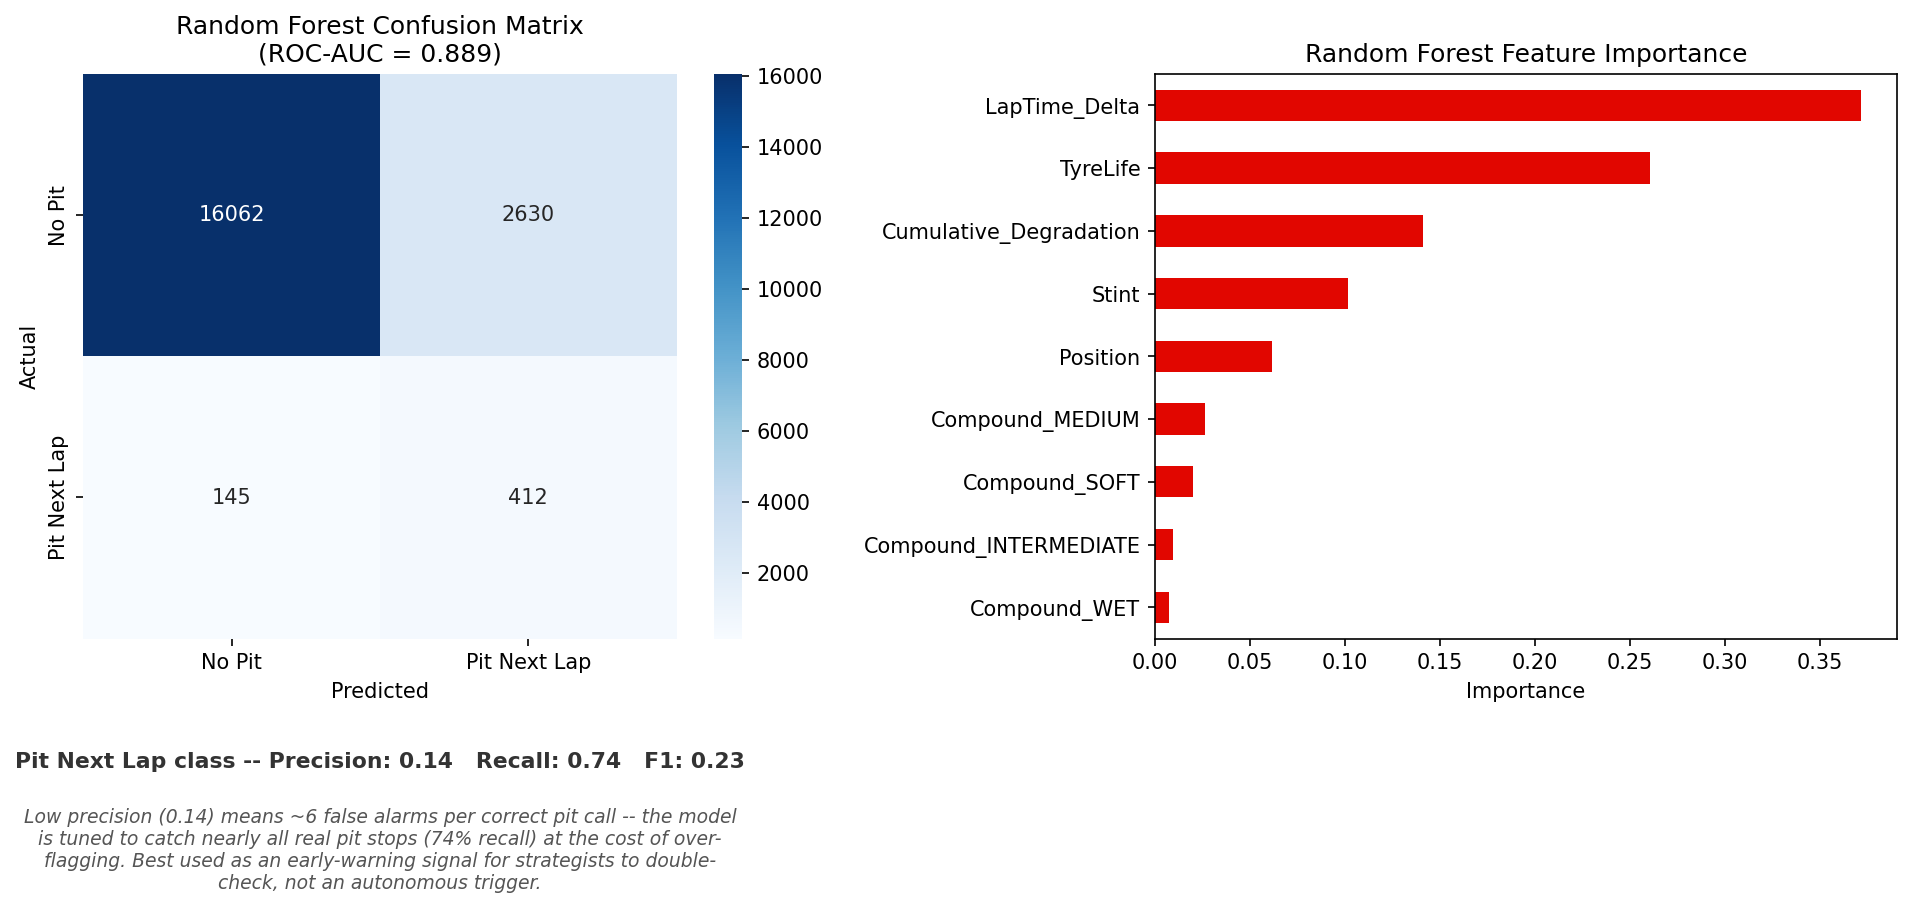

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.6))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Pit', 'Pit Next Lap'], yticklabels=['No Pit', 'Pit Next Lap'])
axes[0].set_title(f'Random Forest Confusion Matrix\n(ROC-AUC = {rf_auc:.3f})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Line 1: the raw numbers
axes[0].text(0.5, -0.20,
             f'Pit Next Lap class -- Precision: {prec:.2f}   Recall: {rec:.2f}   F1: {f1:.2f}',
             transform=axes[0].transAxes, ha='center', va='top', fontsize=10.5,
             fontweight='bold', color='#333333')

# Line 2: the "why" -- turns the raw metric into a strategy recommendation
why_text = (
    "Low precision (0.14) means ~6 false alarms per correct pit call -- the model is "
    "tuned to catch nearly all real pit stops (74% recall) at the cost of over-flagging. "
    "Best used as an early-warning signal for strategists to double-check, not an "
    "autonomous trigger."
)
wrapped = "\n".join(textwrap.wrap(why_text, width=78))
axes[0].text(0.5, -0.30, wrapped,
             transform=axes[0].transAxes, ha='center', va='top', fontsize=9,
             style='italic', color='#555555')

# Feature importance
importances.sort_values().plot(kind='barh', ax=axes[1], color='#E10600')
axes[1].set_title('Random Forest Feature Importance')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('ml_results.png', dpi=150, bbox_inches='tight')
plt.show()


**Reading it:** `LapTime_Delta` (37%) and `TyreLife` (26%) dominate — together they account for nearly two-thirds of the model's decision-making, which lines up with how real pit calls work: teams watch the lap-time trend (is the driver suddenly losing time relative to their own pace?) alongside raw tyre age. `Cumulative_Degradation` (14%) and `Stint` (10%) contribute meaningfully too. `Compound` barely registers on its own — which makes sense, since its effect is already largely captured through `TyreLife` and `Cumulative_Degradation`. The confusion matrix shows the model catches the majority of real pit-next-lap events (high recall on the rare class), at the cost of some false alarms — a reasonable trade-off for a strategy-alerting tool, where missing a real pit window is more costly than a false alarm.

**Precision/recall trade-off (the number ROC-AUC hides):** ROC-AUC (0.889) summarizes ranking quality across *every* possible threshold, but the model that actually ships operates at one threshold, and at that operating point the picture is more mixed: **precision 0.14, recall 0.74, F1 0.23** on the "Pit Next Lap" class. In plain terms, from the confusion matrix above: of the 557 real pit-next-lap laps in the test set, the model correctly flags 412 of them (74% recall, missing only 145). But of the 3,042 laps it flags as "pit next lap," only 412 (14% precision) actually are; the other 2,630 are false alarms. That gap is the deliberate cost of training with `class_weight='balanced'` on a target that's ~97% negative — the model trades precision for recall on purpose, because in this domain a missed pit call (a driver overstaying a worn set because no one flagged it) is a far more expensive mistake than a false alarm (an engineer glances at a flagged driver and decides it isn't time yet).

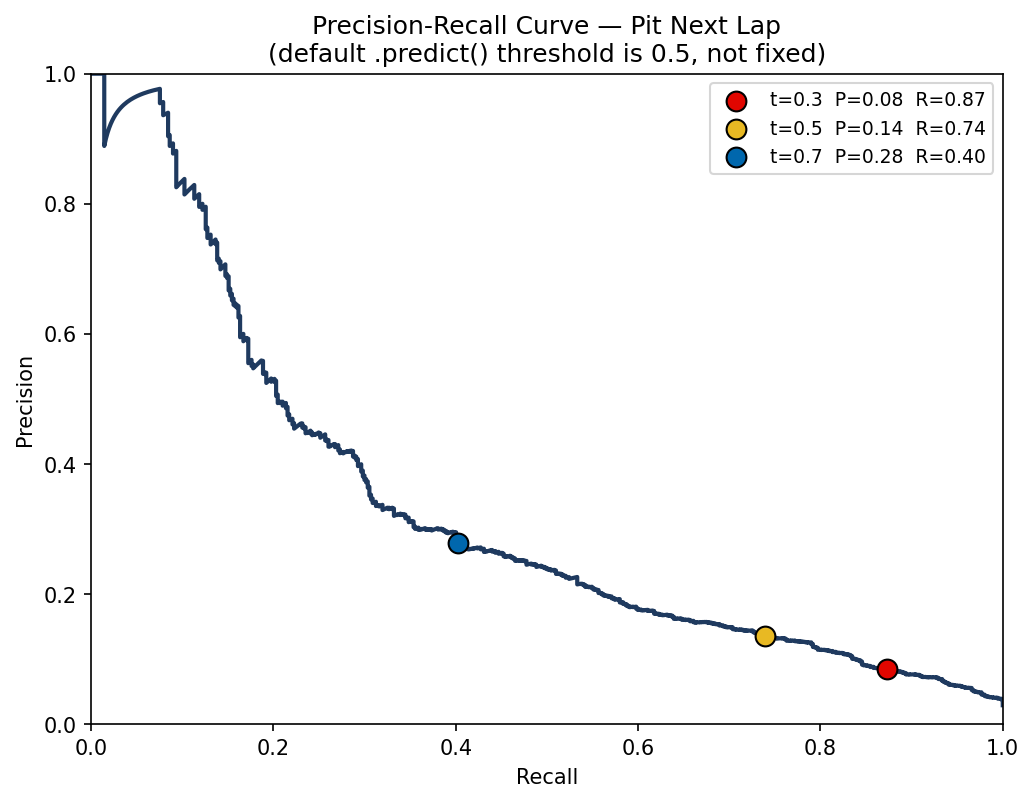

   threshold  precision  recall     f1  laps_flagged0        0.3      0.084   0.873  0.154           57751        0.5      0.135   0.740  0.229           30422        0.7      0.279   0.402  0.329            803

In [ ]:
from sklearn.metrics import precision_recall_curve

precisions_curve, recalls_curve, pr_thresholds = precision_recall_curve(y_test, rf_proba)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(recalls_curve, precisions_curve, color='#1f3a5f', linewidth=2)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve -- Pit Next Lap\n(default .predict() threshold is 0.5, not fixed)')

# Try 3 alternative flagging thresholds instead of the sklearn default (0.5)
marker_colors = ['#E10600', '#E8B923', '#0067AD']
threshold_table = []
for t, c in zip([0.3, 0.5, 0.7], marker_colors):
    pred_t = (rf_proba >= t).astype(int)
    p = precision_score(y_test, pred_t, zero_division=0)
    r = recall_score(y_test, pred_t, zero_division=0)
    f = f1_score(y_test, pred_t, zero_division=0)
    n_flagged = int(pred_t.sum())
    threshold_table.append({'threshold': t, 'precision': round(p, 3), 'recall': round(r, 3),
                             'f1': round(f, 3), 'laps_flagged': n_flagged})
    ax.scatter([r], [p], s=90, zorder=5, color=c, edgecolor='black',
               label=f't={t:.1f}  P={p:.2f}  R={r:.2f}')

ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

pd.DataFrame(threshold_table)


**The 0.5 threshold isn't fixed — it's a dial.** `.predict()` flags a lap the moment predicted probability crosses 0.5, but that cutoff is arbitrary, not something baked into the model. Sweeping it shows the trade-off is fully tunable: at **t=0.3**, precision drops to 0.08 while recall climbs to 0.87 — a wide net that catches almost every real pit stop but flags 5,775 laps to find 557 true ones. At **t=0.7**, precision more than triples to 0.28 while recall falls to 0.40 — a much cleaner signal (803 laps flagged), but now 6 in 10 real pit stops go unflagged. The current default (t=0.5: precision 0.14, recall 0.74, 3,042 flagged) sits deliberately close to the high-recall end, which matches the "a false alarm is cheaper than a missed pit window" framing above — but a team that finds 3,042 flagged laps too noisy to act on could move the threshold toward 0.6–0.7 and trade some missed calls for a signal engineers will actually trust. (For reference, F1 alone peaks even further along that curve, around t≈0.71 — a useful number for a purely statistical balance, though not necessarily the right one for a tool where missing a pit call is costlier than a false alarm.)

**So what — turning this into a strategy call:** `LapTime_Delta` and `TyreLife` together drive ~63% of the model's decisions, and their distributions split cleanly between the two classes. Laps immediately before a pit stop run a median tyre life of **19 laps** (vs. 12 for laps that aren't) and a median `LapTime_Delta` of **about +4.6s off the driver's own baseline pace** (vs. roughly flat, -0.1s, for laps that aren't). A rule of thumb that approximates the model: **once a driver crosses roughly 18-19 laps of tyre life *and* their lap time has drifted about 4-5s or more slower than their own early-stint pace, flag them for a pit window.** `Cumulative_Degradation`, despite being the third-most-important feature, is noisier here because it resets each stint rather than tracking the whole race — treat it as a tie-breaker, not a standalone trigger. Given the precision/recall profile above, this belongs on a race engineer's watch list, not as an autonomous pit trigger: it will flag roughly 6 non-pitting drivers for every 1 real pit call, but it catches 3 out of 4 genuine ones — the right trade when the cost of silence (a driver overstaying a worn set) is much higher than the cost of a false alarm (a second look at a lap-time chart). This threshold is also tunable (see the precision-recall sweep above): teams that want fewer false alarms can move it toward 0.7, accepting more missed calls, while those who'd rather double-check than miss a window can stay near the current default.

## Step 4 — Export for Dashboard

`f1_clean.csv` (already saved in Step 1) is the dashboard source. Below is a 2x2 panel preview matching the four fields requested, built the same way the dashboard would consume the CSV.

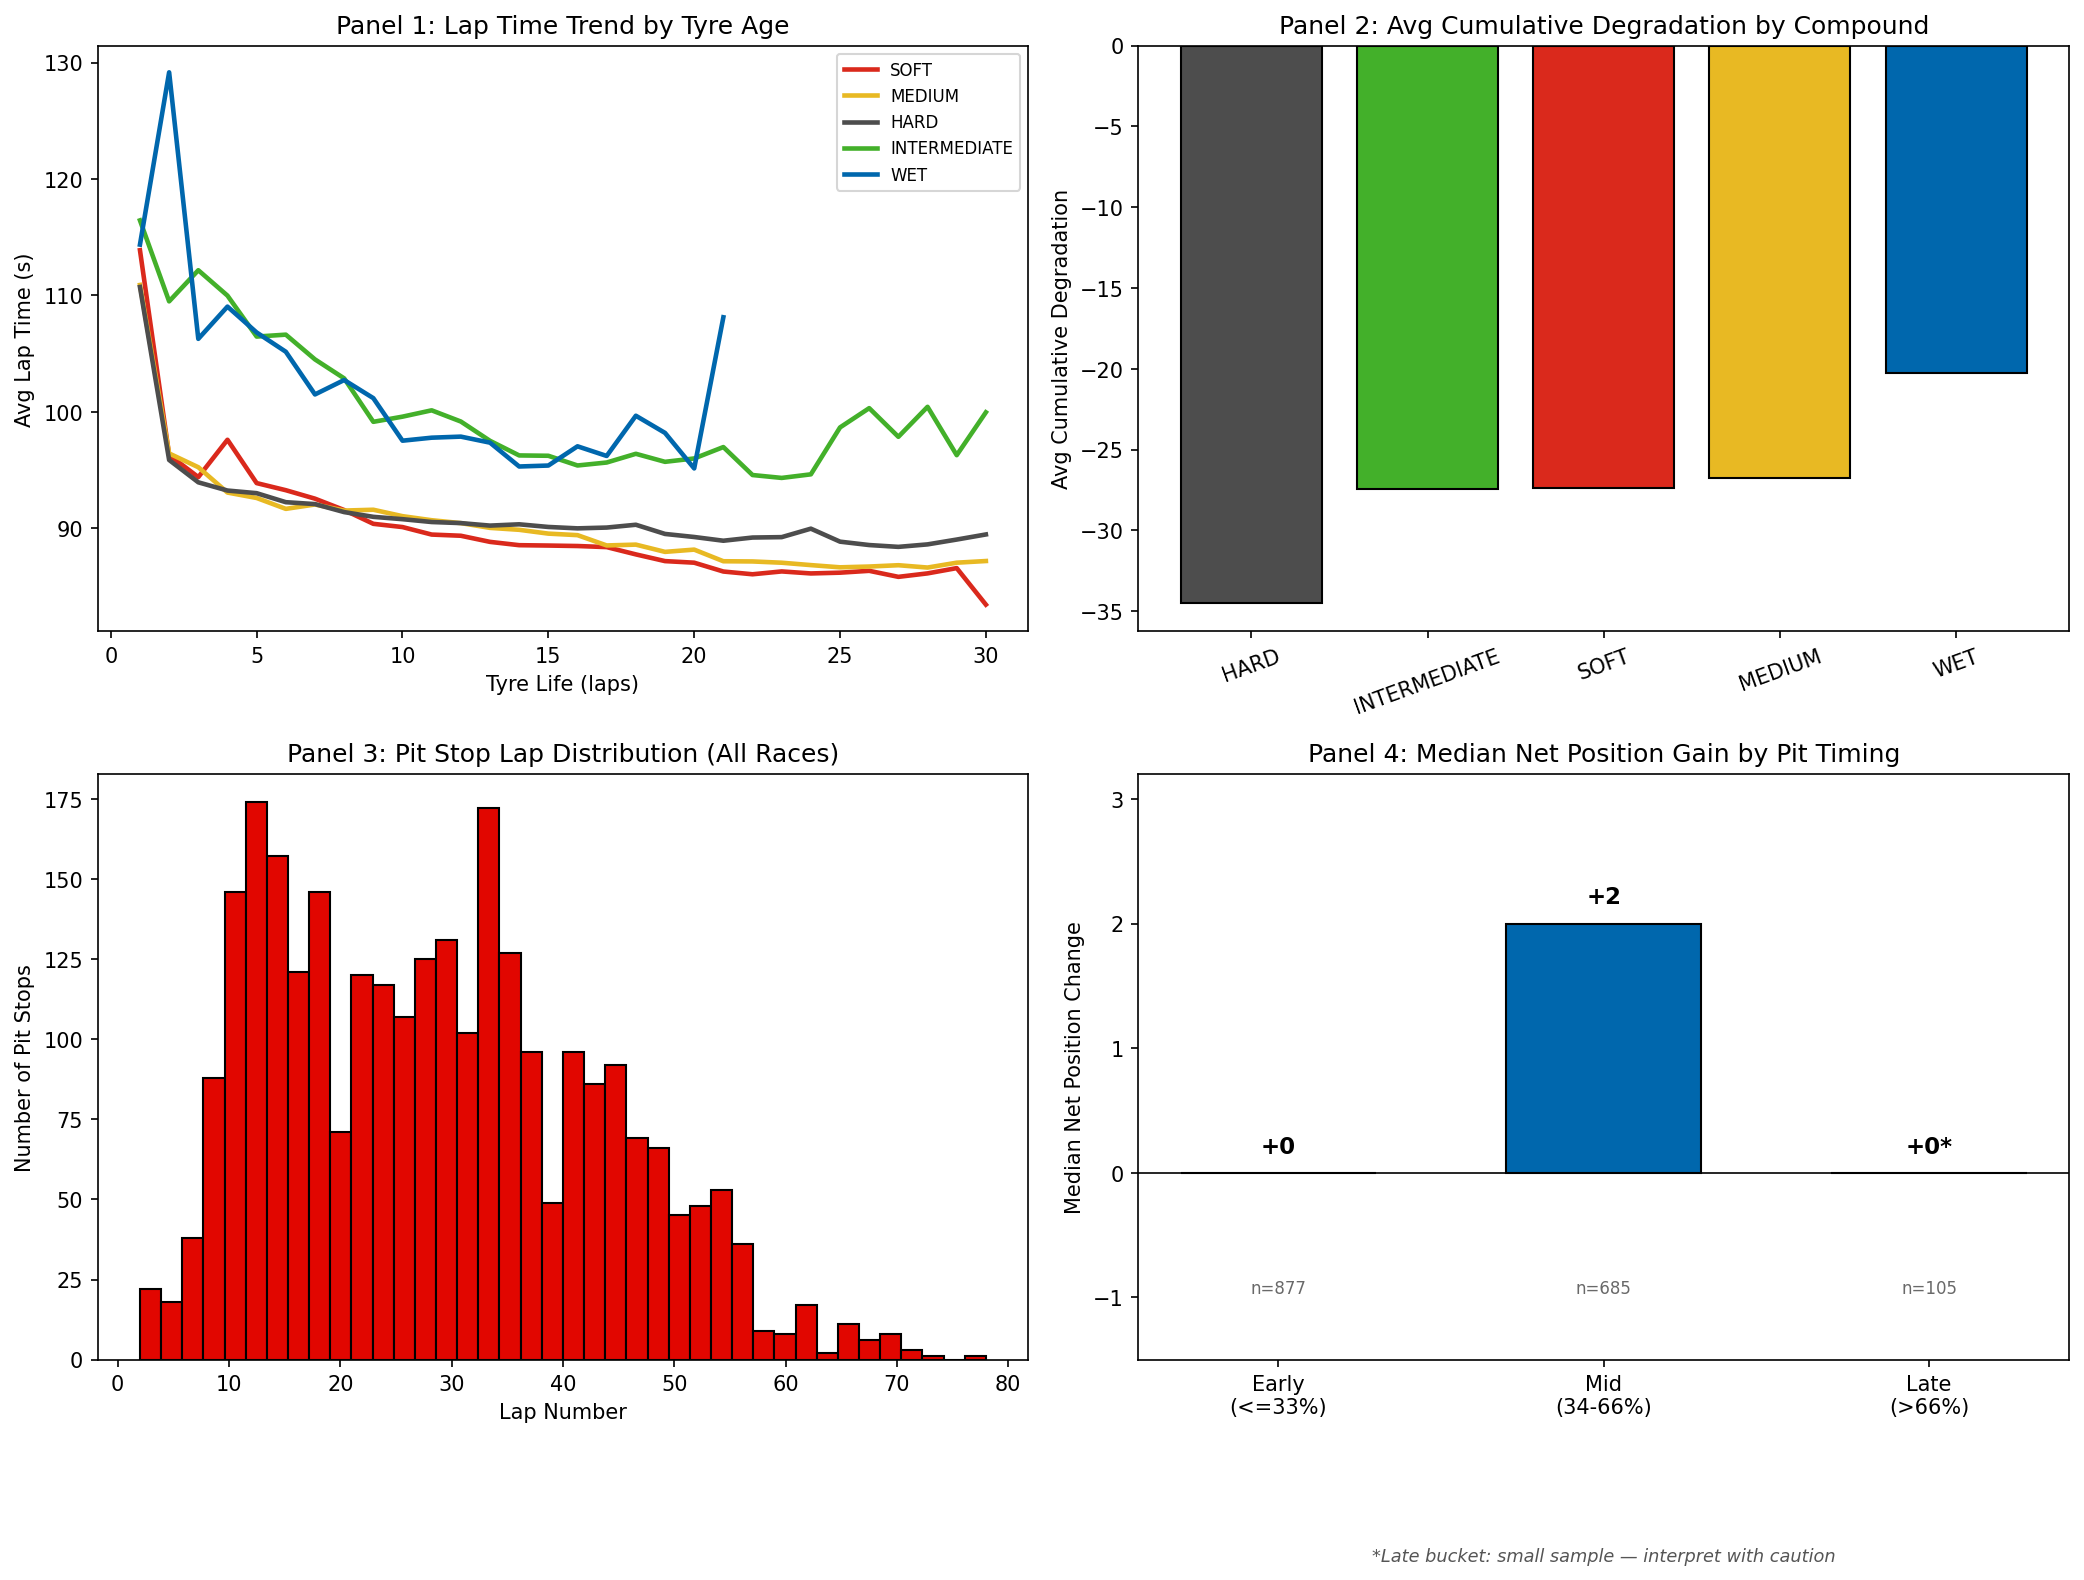

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10.6))

# Panel 1: Lap time trend by TyreLife, colored by Compound (racing laps only)
racing = df[df['Is_Racing_Lap'] == 1]
compound_colors = {'SOFT': '#DA291C', 'MEDIUM': '#E8B923', 'HARD': '#4D4D4D',
                    'INTERMEDIATE': '#43B02A', 'WET': '#0067AD'}
for compound, color in compound_colors.items():
    subset = racing[racing['Compound'] == compound]
    if len(subset) == 0:
        continue
    trend = subset.groupby('TyreLife')['LapTime (s)'].mean()
    trend = trend[trend.index <= 30]  # trim long tail with few samples
    axes[0, 0].plot(trend.index, trend.values, label=compound, color=color, linewidth=2.2)
axes[0, 0].set_title('Panel 1: Lap Time Trend by Tyre Age')
axes[0, 0].set_xlabel('Tyre Life (laps)')
axes[0, 0].set_ylabel('Avg Lap Time (s)')
axes[0, 0].legend(fontsize=8)

# Panel 2: Avg Cumulative_Degradation by Compound
deg_by_compound = racing.groupby('Compound')['Cumulative_Degradation'].mean().sort_values()
axes[0, 1].bar(deg_by_compound.index, deg_by_compound.values,
                color=[compound_colors.get(c, 'gray') for c in deg_by_compound.index],
                edgecolor='black')
axes[0, 1].set_title('Panel 2: Avg Cumulative Degradation by Compound')
axes[0, 1].set_ylabel('Avg Cumulative Degradation')
axes[0, 1].tick_params(axis='x', rotation=20)

# Panel 3: Pit stop lap distribution (all races)
pit_laps = df[df['PitStop'] == 1]['LapNumber']
axes[1, 0].hist(pit_laps, bins=40, color='#E10600', edgecolor='black')
axes[1, 0].set_title('Panel 3: Pit Stop Lap Distribution (All Races)')
axes[1, 0].set_xlabel('Lap Number')
axes[1, 0].set_ylabel('Number of Pit Stops')

# Panel 4: Position impact by pit timing bucket (from Query 4 logic) -- FIXED
# Original bug: Early and Late medians are genuinely 0, so their bars rendered
# at zero height and the panel looked broken/empty rather than "correctly zero."
# Fix: label every bar with its exact value + sample size, and give the axis
# headroom so a 0-height bar still reads as a deliberate data point.
race_length = df.groupby(['Race','Year'])['LapNumber'].max().rename('total_laps')
first_pit = df[df['PitStop']==1].groupby(['Driver','Race','Year'])['LapNumber'].min().rename('first_pit_lap')
net_change = df.groupby(['Driver','Race','Year'])['Position_Change'].sum().rename('net_position_change')
merged = pd.concat([first_pit, net_change], axis=1).join(race_length, on=['Race','Year']).dropna()
merged['pit_pct'] = merged['first_pit_lap'] / merged['total_laps']
merged['bucket'] = pd.cut(merged['pit_pct'], bins=[0, 0.33, 0.66, 1.0],
                            labels=['Early\n(<=33%)', 'Mid\n(34-66%)', 'Late\n(>66%)'])
bucket_stats = merged.groupby('bucket', observed=True)['net_position_change'].agg(['median', 'count'])

ax4 = axes[1, 1]
bars = ax4.bar(bucket_stats.index.astype(str), bucket_stats['median'].values,
                color='#0067AD', edgecolor='black', width=0.6)
ax4.axhline(0, color='black', linewidth=0.8)
ax4.set_ylim(-1.5, 3.2)
bucket_labels = list(bucket_stats.index.astype(str))
for i, (bar, (med, n)) in enumerate(zip(bars, bucket_stats[['median', 'count']].values)):
    label_y = bar.get_height() + 0.12 if bar.get_height() >= 0 else bar.get_height() - 0.28
    star = '*' if bucket_labels[i].startswith('Late') else ''
    ax4.text(bar.get_x() + bar.get_width()/2, label_y, f'{med:+.0f}{star}',
              ha='center', va='bottom' if med >= 0 else 'top', fontsize=11, fontweight='bold')
    ax4.text(bar.get_x() + bar.get_width()/2, -1.0, f'n={int(n)}',
              ha='center', va='bottom', fontsize=8, color='dimgray')
ax4.text(0.5, -0.32, '*Late bucket: small sample -- interpret with caution',
          transform=ax4.transAxes, ha='center', va='top', fontsize=8.5,
          style='italic', color='#555555')
ax4.set_title('Panel 4: Median Net Position Gain by Pit Timing')
ax4.set_ylabel('Median Net Position Change')

plt.tight_layout()
plt.savefig('dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

Panel 4 uses the **median** (per the outlier caveat from Query 4) rather than the mean, so the dashboard doesn't visually mislead viewers with the retirement-driven outliers pulling the "Late" bar to an impossible value. Bars are also labeled directly with the median value and sample size (n) per bucket, since Early and Late both come out to a genuine 0 — without a label, a 0-height bar is indistinguishable from missing data. The Late bucket is additionally flagged with an inline caveat (small n = 105) so a viewer doesn't have to infer the reliability issue from the sample size alone.

## Step 5 — Summary / Talking Points

- **Tyre pecking order holds up exactly as tyre physics predicts:** on worn tyres, SOFT (86.9s avg) < MEDIUM (87.5s) < HARD (89.0s), and the degradation slopes confirm why — SOFT degrades at roughly **4x the rate of HARD** (-0.97 vs. -0.24 per lap of tyre life), so the softer compound's early pace advantage erodes fast.
- **Mid-race pit stops (34–66% of race distance) show the best net outcome:** a median gain of **+2 positions**, vs. 0 for both early (≤33%) and late (>66%) first stops — with the caveat that the "late" bucket's average is skewed by a handful of retirement/incident-affected races and the median is the more trustworthy number there.
- **The pit-next-lap model reaches 0.889 ROC-AUC with Random Forest**, clearly ahead of Logistic Regression's 0.784 — pit decisions hinge on non-linear combinations of signals that tree splits capture better than a linear boundary. But ROC-AUC alone hides the operating-point trade-off: at its actual threshold the model runs **0.14 precision / 0.74 recall (F1 0.23)** on the "Pit Next Lap" class — it catches 74% of real pit-next-lap laps at the cost of ~6 false alarms for every true positive, a deliberate trade given `class_weight='balanced'` on a ~97%-negative target.
- **`LapTime_Delta` and `TyreLife` together drive ~63% of the model's decisions** — the model has effectively learned what race engineers watch for: a driver's pace falling off relative to their own baseline, combined with raw tyre age, well before compound choice matters.
- **Data-quality note carried through to the dashboard:** `Position_Change` contains some physically impossible race-level swings (up to -492 in one case, on a 20-car grid) that look like scoring artifacts around retirements/incidents rather than genuine overtaking — the dashboard's Panel 4 uses medians specifically to avoid amplifying that noise.
- **Strategy translation:** the model's top two features (`LapTime_Delta`, `TyreLife` — 63% of importance) map to a usable rule of thumb: flag a driver for a pit window once tyre life passes **~18-19 laps** *and* lap time has drifted **~4-5s+** slower than their own early-stint pace. Given the precision/recall profile above, that's a watch-list alert for race engineers, not an autonomous trigger.


## If I Had More Time

- **New feature — gap to the car ahead/behind.** Real pit calls weigh track position relative to rivals (pitting into clean air vs. into traffic), which `Position` alone doesn't capture. A gap-in-seconds feature could sharpen the model, especially around the borderline cases where precision currently suffers.
- **Try gradient boosting (XGBoost/LightGBM) alongside Random Forest.** Boosted trees often edge out RF on tabular classification like this, and their native imbalance handling (`scale_pos_weight`) is worth comparing head-to-head against `class_weight='balanced'` on both ROC-AUC and the precision-recall trade-off above.
- **Validate degradation slopes against public tyre-supplier data.** The `Cumulative_Degradation` slopes (SOFT degrading ~4x faster than HARD) match expectations, but cross-checking them against Pirelli's published compound characteristics would be a good sanity check before leaning on that feature for real strategy calls.
- **A circuit-aware model.** Query 2 showed pit timing varies a lot by track — street circuits pit far earlier than others. A single global model may be averaging over meaningfully different strategic environments; adding a circuit feature (or fitting per-circuit models) could sharpen predictions rather than learning one blended pattern.